<a href="https://colab.research.google.com/github/wesnasimone/IA025_Introducao_Aprendizado_Profundo/blob/main/(2026S2)_Exerc%C3%ADcio_TinyImageNet__Wesna_225843.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA025 - Exercício: TinyImageNet


## Coloque seu nome

In [ ]:
# TODO: imprima o seu nome completo
print("Wesna Simone Bulla de Araujo")

Wesna Simone Bulla de Araujo


In [ ]:
!pip install pytorch_lightning torchmetrics torchinfo -q

## Conceitos

In [ ]:
import torch
import torchinfo
import numpy as np
from skimage.data import cat
from torchvision import transforms
from torchvision import models
import matplotlib.pyplot as plt


## Data Augmentation

array([[[143, 120, 104],
        [143, 120, 104],
        [141, 118, 102],
        ...,
        [ 45,  27,  13],
        [ 45,  27,  13],
        [ 45,  27,  13]],

       [[146, 123, 107],
        [145, 122, 106],
        [143, 120, 104],
        ...,
        [ 46,  29,  13],
        [ 45,  29,  13],
        [ 47,  30,  14]],

       [[148, 126, 112],
        [147, 125, 111],
        [146, 122, 109],
        ...,
        [ 48,  28,  17],
        [ 49,  29,  18],
        [ 50,  30,  19]],

       ...,

       [[ 92,  58,  30],
        [105,  71,  43],
        [132,  98,  71],
        ...,
        [172, 145, 138],
        [172, 145, 138],
        [172, 145, 138]],

       [[128,  92,  60],
        [139, 103,  71],
        [134,  95,  64],
        ...,
        [166, 142, 132],
        [166, 142, 132],
        [167, 143, 133]],

       [[139, 103,  71],
        [127,  88,  57],
        [125,  86,  53],
        ...,
        [161, 137, 127],
        [161, 137, 127],
        [162, 138, 128]]], dtype=uint8)
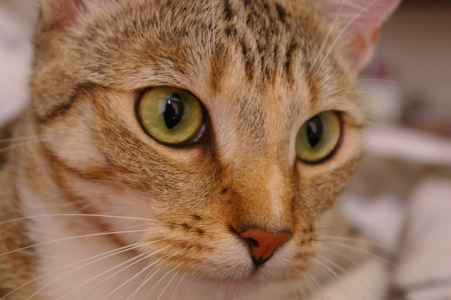

In [ ]:
cat_ndarray = cat()
cat_ndarray

In [ ]:
cat_tensor_manual = torch.from_numpy(cat_ndarray)
cat_tensor_manual

tensor([[[143, 120, 104],
         [143, 120, 104],
         [141, 118, 102],
         ...,
         [ 45,  27,  13],
         [ 45,  27,  13],
         [ 45,  27,  13]],

        [[146, 123, 107],
         [145, 122, 106],
         [143, 120, 104],
         ...,
         [ 46,  29,  13],
         [ 45,  29,  13],
         [ 47,  30,  14]],

        [[148, 126, 112],
         [147, 125, 111],
         [146, 122, 109],
         ...,
         [ 48,  28,  17],
         [ 49,  29,  18],
         [ 50,  30,  19]],

        ...,

        [[ 92,  58,  30],
         [105,  71,  43],
         [132,  98,  71],
         ...,
         [172, 145, 138],
         [172, 145, 138],
         [172, 145, 138]],

        [[128,  92,  60],
         [139, 103,  71],
         [134,  95,  64],
         ...,
         [166, 142, 132],
         [166, 142, 132],
         [167, 143, 133]],

        [[139, 103,  71],
         [127,  88,  57],
         [125,  86,  53],
         ...,
         [161, 137, 127],
        

In [ ]:
cat_tensor = transforms.ToTensor()(cat_ndarray) #essa função já normaliza
cat_tensor

tensor([[[0.5608, 0.5608, 0.5529,  ..., 0.1765, 0.1765, 0.1765],
         [0.5725, 0.5686, 0.5608,  ..., 0.1804, 0.1765, 0.1843],
         [0.5804, 0.5765, 0.5725,  ..., 0.1882, 0.1922, 0.1961],
         ...,
         [0.3608, 0.4118, 0.5176,  ..., 0.6745, 0.6745, 0.6745],
         [0.5020, 0.5451, 0.5255,  ..., 0.6510, 0.6510, 0.6549],
         [0.5451, 0.4980, 0.4902,  ..., 0.6314, 0.6314, 0.6353]],

        [[0.4706, 0.4706, 0.4627,  ..., 0.1059, 0.1059, 0.1059],
         [0.4824, 0.4784, 0.4706,  ..., 0.1137, 0.1137, 0.1176],
         [0.4941, 0.4902, 0.4784,  ..., 0.1098, 0.1137, 0.1176],
         ...,
         [0.2275, 0.2784, 0.3843,  ..., 0.5686, 0.5686, 0.5686],
         [0.3608, 0.4039, 0.3725,  ..., 0.5569, 0.5569, 0.5608],
         [0.4039, 0.3451, 0.3373,  ..., 0.5373, 0.5373, 0.5412]],

        [[0.4078, 0.4078, 0.4000,  ..., 0.0510, 0.0510, 0.0510],
         [0.4196, 0.4157, 0.4078,  ..., 0.0510, 0.0510, 0.0549],
         [0.4392, 0.4353, 0.4275,  ..., 0.0667, 0.0706, 0.

In [ ]:
# Normalização do imageNet
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformed_tensor = transform_norm(cat_ndarray)
transformed_tensor.shape

torch.Size([3, 300, 451])

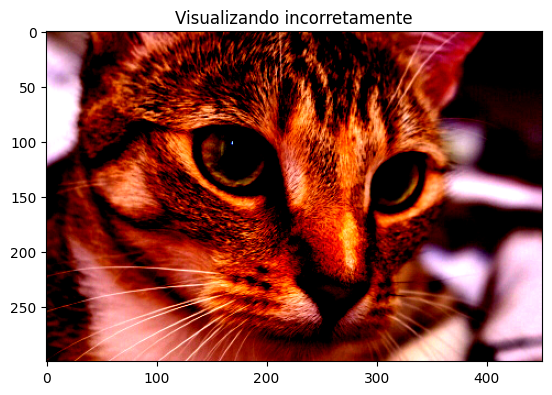

In [ ]:
# Corrigindo para padrão channel-last do numpy
display_image = transformed_tensor.permute(1, 2, 0)

# As intensidades não são mais originais...
plt.title("Visualizando incorretamente")
plt.imshow(display_image)

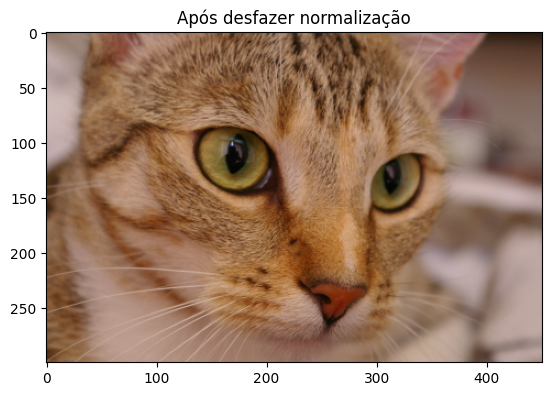

In [ ]:
# Reshape necessário para o broadcast das operações
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

unnormalized_image = transformed_tensor * std + mean

# Permute back to HWC for displaying and clip values to [0, 1]
unnormalized_image_display = unnormalized_image.permute(1, 2, 0).clamp(0, 1)

plt.imshow(unnormalized_image_display)
plt.title('Após desfazer normalização')
plt.show()

In [ ]:
# Normalização do imageNet e aplicação de data augmentation com o transforms.compose
transform_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(size=(224, 224))
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

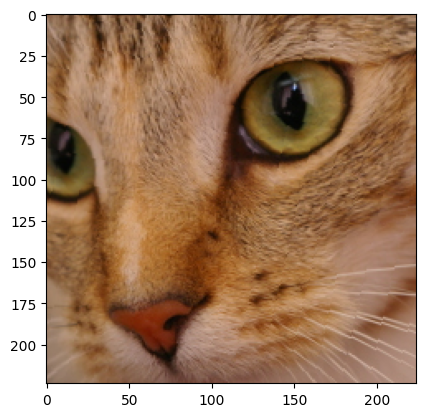

In [ ]:
plt.imshow(transform_aug(cat_ndarray).permute(1, 2, 0))

## Métricas de Classificação

In [ ]:
from sklearn.metrics import classification_report

# Example binary classification data
y_true_binary = [0, 1, 2, 0, 1, 1, 0, 1, 0, 1]
y_pred_binary = [0, 1, 1, 2, 1, 0, 0, 1, 1, 0]

print("Classification Report (Binary Example):\n")
print(classification_report(y_true_binary, y_pred_binary))

Classification Report (Binary Example):

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.60      0.60      0.60         5
           2       0.00      0.00      0.00         1

    accuracy                           0.50        10
   macro avg       0.37      0.37      0.37        10
weighted avg       0.50      0.50      0.50        10



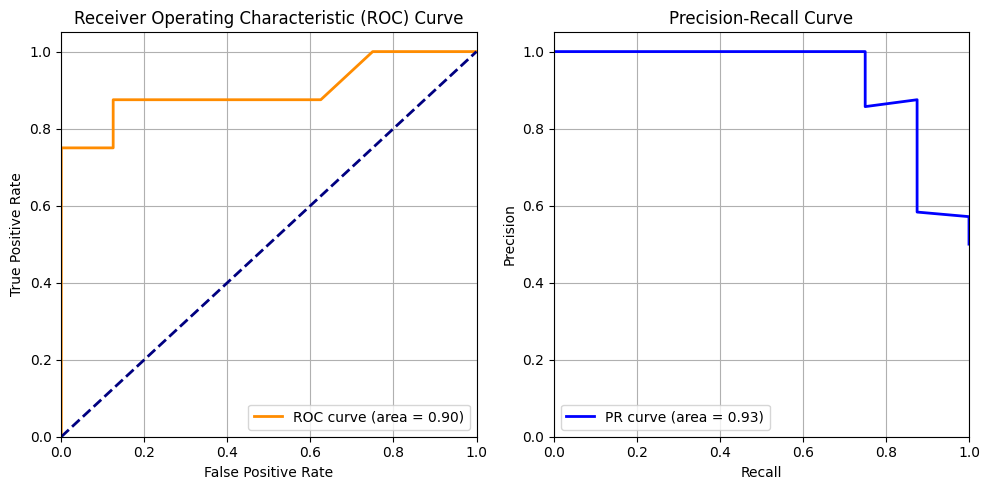

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import numpy as np

# y_true: actual binary labels
# y_scores: probability scores for the positive class
y_true_metrics = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])
y_scores_metrics = np.array([0.1, 0.2, 0.6, 0.3, 0.4, 0.25, 0.15, 0.45, 0.7, 0.8, 0.2, 0.9, 0.55, 0.65, 0.75, 0.85])

# --- ROC-AUC Plot ---
fpr, tpr, _ = roc_curve(y_true_metrics, y_scores_metrics)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

# --- PR-AUC Plot ---
precision, recall, _ = precision_recall_curve(y_true_metrics, y_scores_metrics)
pr_auc = auc(recall, precision)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

## Carregando pesos pré-treinados para Transfer Learning

In [ ]:
# Forma moderna. Código: https://github.com/pytorch/vision/blob/main/torchvision/models/efficientnet.py
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

In [ ]:
torchinfo.summary(model, depth=10, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 1000]                 --
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 16, 112, 112]         --
│    │    │    └─Sequential: 4-1                        [1, 16, 112, 112]         --
│    │    │    │    └─Conv2dNormActivation: 5-1         [1, 32, 112, 112]         --
│    │    │    │    │    └─Conv2d: 6-1                  [1,

## Exemplo no MNIST

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
100%|██████████| 9.91M/9.91M [00:00<00:00, 85.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 8.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 111MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.86MB/s]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1     │ DepthwiseSeparableConv │     59 │ train │     0 │
│ 1 │ pool1     │ MaxPool2d              │      0 │ train │     0 │
│ 2 │ conv2     │ DepthwiseSeparableConv │    752 │ train │     0 │
│ 3 │ pool2     │ MaxPool2d              │      0 │ train │     0 │
│ 4 │ gap       │ AdaptiveAvgPool2d      │      0 │ train │     0 │
│ 5 │ fc1       │ Linear                 │    330 │ train │     0 │
│ 6 │ loss_fn   │ CrossEntropyLoss       │      0 │ train │     0 │
│ 7 │ train_acc │ MulticlassAccuracy     │      0 │ train │     0 │
│ 8 │ val_acc   │ MulticlassAccuracy     │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0.005                                                                      
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Epoch 0 - Validation Accuracy: 0.6602

Classification Report:
              precision    recall  f1-score   support

           0     0.6126    0.9158    0.7341       986
           1     0.9866    0.9616    0.9739      1145
           2     0.6485    0.4928    0.5600      1037
           3     0.9136    0.7283    0.8105      1016
           4     0.9069    0.7661    0.8306       992
           5     0.7649    0.3003    0.4313       899
           6     0.5505    0.7643    0.6400       963
           7     0.3953    0.9700    0.5617      1035
           8     0.9822    0.1703    0.2902       975
           9     0.6541    0.4114    0.5051      1016

    accuracy                         0.6567     10064
   macro avg     0.7415    0.6481    0.6338     10064
weighted avg     0.7436    0.6567    0.6408     10064

ROC-AUC (OVR): 0.9712


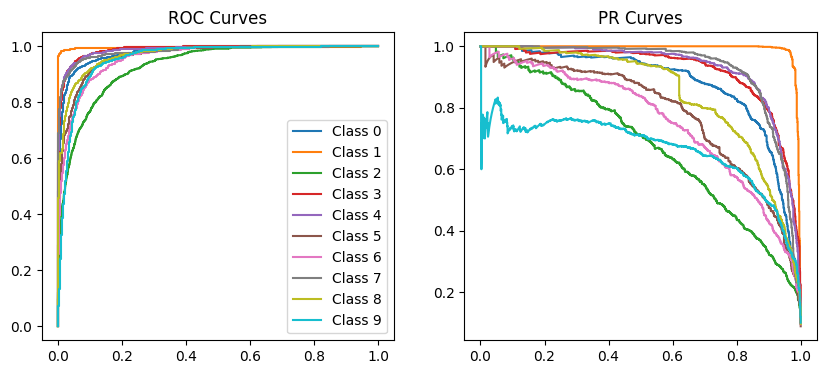

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


In [ ]:
import os
import torch
import pytorch_lightning as pl
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc

class MNISTDataModule(pl.LightningDataModule):
    def __init__(self):
        super().__init__()
        self.train_transform = transforms.Compose([
            transforms.RandomRotation(10),
            transforms.RandomAffine(0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        self.val_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def setup(self, stage=None):
        self.train_ds = MNIST(os.getcwd(), train=True, download=True, transform=self.train_transform)
        self.val_ds = MNIST(os.getcwd(), train=False, download=True, transform=self.val_transform)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=32, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=32)

class DepthwiseSeparableConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=1):
        super().__init__()
        self.depthwise = torch.nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                         padding=padding, groups=in_channels, bias=False)
        self.bn1 = torch.nn.BatchNorm2d(in_channels)
        self.relu = torch.nn.ReLU()
        self.pointwise = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = torch.nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.relu(self.bn2(self.pointwise(x)))
        return x

class MNISTCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(1, 16, kernel_size=3, padding=1)
        self.pool1 = torch.nn.MaxPool2d(2)
        self.conv2 = DepthwiseSeparableConv(16, 32, kernel_size=3, padding=1)
        self.pool2 = torch.nn.MaxPool2d(2)
        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = torch.nn.Linear(32, 10)
        self.loss_fn = torch.nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.validation_step_outputs = []

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc1(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, on_step=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        self.val_acc(logits, y)
        self.validation_step_outputs.append({"probs": probs.detach().cpu(), "preds": preds.detach().cpu(), "targets": y.detach().cpu()})
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        if self.trainer.sanity_checking:
            return

        all_probs = torch.cat([x["probs"] for x in self.validation_step_outputs]).numpy()
        all_preds = torch.cat([x["preds"] for x in self.validation_step_outputs]).numpy()
        all_targets = torch.cat([x["targets"] for x in self.validation_step_outputs]).numpy()

        # Clear immediately after extracting to avoid memory retention
        self.validation_step_outputs.clear()

        avg_acc = self.val_acc.compute()
        print(f"\nEpoch {self.current_epoch} - Validation Accuracy: {avg_acc:.4f}")
        print("\nClassification Report:")
        print(classification_report(all_targets, all_preds, digits=4))

        roc_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr')
        print(f"ROC-AUC (OVR): {roc_auc:.4f}")

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        for i in range(10):
            fpr, tpr, _ = roc_curve((all_targets == i).astype(int), all_probs[:, i])
            plt.plot(fpr, tpr, label=f'Class {i}')
        plt.title("ROC Curves")
        plt.legend()

        plt.subplot(1, 2, 2)
        for i in range(10):
            p, r, _ = precision_recall_curve((all_targets == i).astype(int), all_probs[:, i])
            plt.plot(r, p, label=f'Class {i}')
        plt.title("PR Curves")
        plt.show()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=0.01)

from pytorch_lightning.callbacks import TQDMProgressBar

module = MNISTCNN()
datamodule = MNISTDataModule()
trainer = pl.Trainer(max_epochs=1, callbacks=[TQDMProgressBar(refresh_rate=10)])
trainer.fit(module, datamodule)

# Exercício
O enunciado é simples: execute Transfer Learning de um peso pré-treinado da EfficientNet-b0 utilizando o dataset TinyImageNet.
* Experimente com congelamento de camadas.
* Pode usar alguma modelagem pronta do TinyImageNet.
* Matenha a sua CrossEntropyLoss e loop de treino na mão do exercício anterior.
* Inicialize os pesos pré-treinados, use data augmentation. Aproveite para normalizar os dados corretamente considerando o que foi usado no pré-treino!
* Reporte métricas além da acurácia, F1-score, plote o gráfico de PR-AUC e ROC-AUC.

DESAFIOS OPCIONAIS:
1) Modele o dataset "do zero".
2) Também treine no CIFAR10.
3) Tente treinar SEM utilizar o peso pré-treinado e compare os experimentos.


In [ ]:
# Um dicionário de hiperparâmetros é uma forma de organizar parâmetros do seu experimento.
# Você pode adicionar mais parâmetros, experimente muda-los!
hyperparameters_tiny = {
    "batch_size": 32,
    "learning_rate": 0.0001,
    "nin": 3, # exemplo para entrada com 3 canais RGB
    "nout": 200,  # exemplo para 10 classes de saída
    # Qualquer parâmetro do código pode ser colocado aqui, parametrizando todo o experimento com um único dicionário
}

## TinyImageNet
Utilize o código abaixo que lê uma imagem e classe do TinyImageNet para criar um Dataset PyTorch para o treinamento, ou utilize uma classe pronta do Dataset.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import os
import glob
import torchvision
import os
import torch
from torch.utils.data import DataLoader
import requests
import pytorch_lightning as pl
from torchvision import transforms

In [ ]:
#Configura drive --> acabei que não usando porque ficou muito mais lento
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
class TinyImageNet(torch.utils.data.Dataset):
    def __init__(self, caminho_arquivo, train=False):
        super().__init__()
        self.train = train
        self.caminho_arquivo = caminho_arquivo

        caminho_zip = os.path.join(self.caminho_arquivo, 'tiny-imagenet-200.zip')

        #verifica se a pasta existe
        os.makedirs(self.caminho_arquivo, exist_ok=True)

        #faz download e deszipa
        if os.path.exists(caminho_zip):
          print('O arquivo está baixado e disponível!')
        else:
          print('O arquivo ainda não foi baixado ou não existe.')
          print('Baixando...')

          url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'

          resposta = requests.get(url)
          with open(caminho_zip, 'wb') as arquivo:
              arquivo.write(resposta.content)

          print('Descompactando...')
          !unzip -q "$caminho_zip" -d "$self.caminho_arquivo"
          print('Processo concluído!')

        #organizando os dados
        if self.train == True:
          nome = self.caminho_arquivo + "/tiny-imagenet-200/train/"
        else:
          nome = self.caminho_arquivo + "/tiny-imagenet-200/val/"
          nome_label = "val_annotations.txt"
          class_name_file_val = [line.split("\t") for line in open(os.path.join(nome, nome_label), 'r').readlines()]
          self.class_names_dict_val = {line[0]: line[1].split(',')[0].strip() for line in class_name_file_val}

        #classes presentes no TinyImageNet
        self.classes = sorted(os.path.basename(path) for path in glob.glob(self.caminho_arquivo + "/tiny-imagenet-200/train/*"))
        class_name_file = [line.split("\t") for line in open(os.path.join(self.caminho_arquivo + "/tiny-imagenet-200", "words.txt"), 'r').readlines()]

        #associa nome com label string
        self.class_names_dict = {line[0]: line[1].split(',')[0].strip() for line in class_name_file}

        #associa nome com label numerica
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}

        #as imagens propriamente ditas
        self.base_dataset = list(glob.iglob(nome + "**/images/*.JPEG", recursive=True))


    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image_nome = self.base_dataset[idx]
        image = Image.open(image_nome).convert('RGB') #garante que todas as imagens de fato terão 3 canais
        image = np.array(image, dtype=np.uint8)       # para que o torch consiga de fato normalizar entre 0 e 1 automaticamente

        #faz data augmentation e normalização e identifica a correta label no dicionario
        #data augmentation da validação é só a normalização
        if self.train == True:
          image = self.data_augmentation_train(image)
          target_name = os.path.basename(image_nome.split("/images")[0])
        else:
          image = self.data_augmentation_val(image)
          target_name = self.class_names_dict_val[image_nome.split('/')[-1]]

        label = self.class_to_idx[target_name]              #index do label
        label_string = self.class_names_dict[target_name]   #label string

        return image, label, label_string

    def data_augmentation_train(self, array):
        transform_norm = transforms.Compose([
                         transforms.ToTensor(),
                         transforms.RandomHorizontalFlip(p=0.5),
                         transforms.ColorJitter(brightness=0.5, contrast=1, saturation=0.1, hue=0.5),
                         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

        ])
        return transform_norm(array)

    def data_augmentation_val(self, array):
        transform_norm = transforms.Compose([
                         transforms.ToTensor(),
                         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

        ])
        return transform_norm(array)

## Inicialize o Dataloader, e visualize se os dados que vão entrar na rede fazem sentido!

In [ ]:
class DataModuleTiny(pl.LightningDataModule):
    def __init__(self, hparams, caminho_arquivo):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

        self.caminho_arquivo = caminho_arquivo

    def setup(self, stage=None):
        self.train = TinyImageNet(self.caminho_arquivo, train=True)
        self.val = TinyImageNet(self.caminho_arquivo, train=False)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)

In [ ]:
# TODO visualize o batch com o dataloader
#caminho_arquivo = '/content/drive/MyDrive/TinyImagenet'
caminho_arquivo = "tiny-imagenet-200"
datamodule_tiny = DataModuleTiny(hyperparameters_tiny, caminho_arquivo)
datamodule_tiny.setup()

O arquivo ainda não foi baixado ou não existe.
Baixando...
Descompactando...
Processo concluído!
O arquivo está baixado e disponível!


In [ ]:
#monta dataloader e verifica shape
train_dataloader_tiny = datamodule_tiny.train_dataloader()
val_dataloader_tiny = datamodule_tiny.val_dataloader()

#visualiza o primeiro batch
primeiro_batch_tiny = next(iter(train_dataloader_tiny))
imagem_tiny, label, label_string= primeiro_batch_tiny
print(f"Imagem Original: {imagem_tiny.shape} --- Label: {len(label)}")
print("input max:", imagem_tiny.abs().max())
print("input min:", imagem_tiny.min())

Imagem Original: torch.Size([32, 3, 64, 64]) --- Label: 32
input max: tensor(2.6400)
input min: tensor(-2.1179)


torch.Size([64, 64, 3])
Label: 110 = iPod


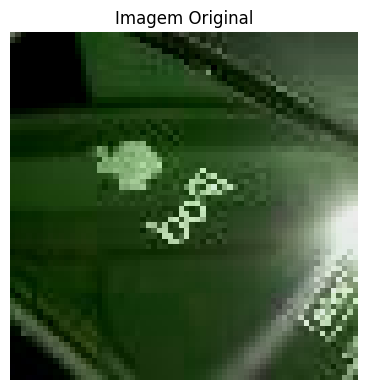

In [ ]:
#Plotar imagens Tiny
imagem_original_tiny = imagem_tiny[1]

#Reshape necessário para o broadcast das operações
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
unnormalized_image = imagem_original_tiny * std + mean

#Permute back to HWC for displaying and clip values to [0, 1]
unnormalized_image_display = unnormalized_image.permute(1, 2, 0).clamp(0, 1)

labels_tiny = label[1]
print(unnormalized_image_display.shape)
print(f'Label: {labels_tiny} = {label_string[1]}')

#Plota imagem
fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

ax1.imshow(unnormalized_image_display)
ax1.set_title('Imagem Original')
ax1.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
import torch.nn.functional as F

class MyCrossEntropyLoss():
    """
    TODO Implemente a classe que faz softmax e entropia cruzada, sem usar as funções prontas do PyTorch (nn ou functional),
    somente operações sobre tensores.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def __call__(self, logits, labels):
      #passo1: tranformar labels em one_hot
      label_one_hot_encoded = F.one_hot(labels, self.num_classes)

      # Subtrair o maior logit para evitar overflow
      logits_stable = logits - torch.max(logits, dim=1, keepdim=True).values

      #passo2: calcular probabilidades (softmax)
      exponencial = torch.exp(logits_stable)
      probabilidade = exponencial/torch.sum(exponencial, dim=1, keepdim=True)
      probabilidade = torch.clamp(probabilidade, min=1e-8)

      #passo3: calcular a entropia cruzada --> loss
      loss = -(torch.sum(label_one_hot_encoded*torch.log(probabilidade))) / logits_stable.shape[0]

      return loss, probabilidade

In [ ]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
from torchvision import models

class MyModel(torch.nn.Module):
    """
    Crie uma CNN com múltiplas camadas.
    Lembre se de aumentar o número de canais para possibilitar a criação de features ricas.
    Utilize não linearidades, e MaxPool ou outra estratégia de pooling.
    No final, adicione uma camada linear para classificação, após linearizar as features finais da forma que preferir.
    Sugestão: AvgPool nas dimensões espaciais.
    """
    def __init__(self, hparams, freeze=True, bias=True):
        super().__init__()

        self.nin = hparams["nin"]
        self.nout = hparams["nout"]
        self.bias = bias
        self.freeze = freeze

        #Encoder (EfficientNet-B0) pré-treinado
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.encoder = models.efficientnet_b0(weights=weights)

        #mas o efficientnet termina com uma camada linear de dimensão 1000, então precisamos remover essa camada
        #para conseguir adaptar ao nosso classificador de 200 classes
        self.encoder.classifier = nn.Identity()

        #congela ou não o encoder
        #se freeze é igual a False o encoder é congelado
        for param in self.encoder.features.parameters():
            param.requires_grad = self.freeze


        #Decoder --> meu modelo para a tarefa de classificação
        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.layer1 = nn.Linear(1280, 512)    #1280 --> saida da efficientnet antes da camada linear
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(512, self.nout)


    def forward(self, input_tensor):

        x = self.encoder.features(input_tensor)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.fc1(x)

        return x

## Loop de Treino: Re-use seu loop de treino do exercício anterior.


In [ ]:
#Configuração da gpu se disponivel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy, F1Score, Precision, Recall
from torchmetrics.classification import MulticlassROC, MulticlassAveragePrecision
from sklearn.metrics import auc

epocas = 50
n_out = hyperparameters_tiny["nout"]

#inicializa modelo
model_tiny = MyModel(hyperparameters_tiny, freeze=False, bias=True)
model_tiny.to(device)

#inicializar o otimizador
otimizador = torch.optim.Adam(model_tiny.parameters(), lr=hyperparameters_tiny["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out)
f1 = F1Score(task="multiclass", num_classes=n_out, average="macro")
precision = Precision(task="multiclass", num_classes=n_out, average="macro")
recall = Recall(task="multiclass", num_classes=n_out, average="macro")

loss_treino_tiny = []
loss_valid_tiny = []
acc_valid_epoca_tiny = []
f1_valid_epoca_tiny = []
precision_valid_epoca_tiny = []
recall_valid_epoca_tiny = []
acc_final_all_epoca_tiny = []


for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0


  ################### LOOP TREINO #####################
  model_tiny.train()
  with trange(len(train_dataloader_tiny), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader_tiny):
      x, label, _ = batch
      x = x.to(device)
      label = label.to(device)

      #PASSO 1: forward
      y = model_tiny(x)

      loss, probabilidade = cross_entropia(y, label)

      #acurácia do batch
      acc_train = (torch.argmax(y, dim=1) == label).float().mean()
      loss_batch_treino += loss.item()

      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))
      acc.reset()
      f1.reset()


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader_tiny) #loss por epoca
    loss_treino_tiny.append(loss_epoca)


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader_tiny), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model_tiny.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader_tiny):
        x, label, _ = batch
        x = x.to(device)
        label = label.to(device)

        #PASSO 1: forward
        y = model_tiny(x)

        loss, probabilidade = cross_entropia(y, label)

        # Predição
        pred = torch.argmax(y, dim=1)
        acc_valid = (torch.argmax(y, dim=1) == label).float().mean()

        #acumula as métricas nos batches
        acc.update(y.cpu(), label.cpu())
        f1.update(y.cpu(), label.cpu())
        precision.update(y.cpu(), label.cpu())
        recall.update(y.cpu(), label.cpu())


        loss_batch_valid += loss.item()
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader_tiny) #loss por epoca
      loss_valid_tiny.append(loss_epoca_valid)



      ######## Guarda métricas em relação a época ###########

      # Calcula métricas usando toda a validação
      acc_final_all = acc.compute()
      f1_final = f1.compute()
      precision_final = precision.compute()
      recall_final = recall.compute()


      # Salva as métricas
      f1_valid_epoca_tiny.append(f1_final.item())
      precision_valid_epoca_tiny.append(precision_final.item())
      recall_valid_epoca_tiny.append(recall_final.item())
      acc_final_all_epoca_tiny.append(acc_final_all.item())
      acc.reset()
      f1.reset()
      precision.reset()
      recall.reset()


Loop Valid: 100%|██████████| 313/313 [00:02<00:00, 151.94it/s, desc=[Epoca 50] Loss: 3.0101 Acc: 0.3125]


## Compute métricas na validação, incluido plots de ROC-AUC e PR-AUC

In [ ]:
#Configura novamente o dicionario para atualizar o tamanho do batch para 1 para rodar um novo loop de validação
#para computar as curvas ROC e PR
hyperparameters_tiny = {
    "batch_size": 1,
    "learning_rate": 0.0001,
    "nin": 3, # exemplo para entrada com 3 canais RGB
    "nout": 200,  # exemplo para 10 classes de saída
    # Qualquer parâmetro do código pode ser colocado aqui, parametrizando todo o experimento com um único dicionário
}

In [ ]:
#Constroi novo dataloader para validação com batch igual a 1
datamodule_tiny = DataModuleTiny(hyperparameters_tiny, caminho_arquivo)
datamodule_tiny.setup()
val_dataloader_tiny1 = datamodule_tiny.val_dataloader()


#salva o label e a probabilidade
y_prob = []
y_real = []

########### Loop validação ##########
model_tiny.eval()
with torch.no_grad():
    for batch in val_dataloader_tiny1:

        x, label, _ = batch

        x = x.to(device)
        label = label.to(device)

        y = model_tiny(x)

        _, probabilidade = cross_entropia(y, label)

        #guarda somente na CPU
        y_prob.append(probabilidade.cpu())
        y_real.append(label.cpu())

y_prob = torch.cat(y_prob)
y_real = torch.cat(y_real)

O arquivo está baixado e disponível!
O arquivo está baixado e disponível!


In [ ]:
#calcula métricas para calcular os coeficientes e as curvas ROC e PR
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
import numpy as np

#como são 200 classes é preciso transformar as classes em representações 0 ou 1
y_real_bin = label_binarize(y_real.numpy(), classes=np.arange(n_out))

fpr = {}
tpr = {}
roc_auc = {}
pr_auc_classes = []
r = {}
p = {}

for i in range(n_out):
    fpr[i], tpr[i], _ = roc_curve(y_real_bin[:, i], y_prob[:, i].numpy())               #calcula curva roc para cada classe
    p[i], r[i], _ = precision_recall_curve(y_real_bin[:, i], y_prob[:, i].numpy())      #calcula curva pr para cada classe
    pr_auc_value = auc(r[i], p[i])
    pr_auc_classes.append(pr_auc_value)


In [ ]:
#Coeficientes das curvas ROC e PR
roc_auc = roc_auc_score(y_real, y_prob, multi_class='ovr')
pr_auc = np.mean(pr_auc_classes)
print('PR-AUC:', pr_auc)
print(f'roc_auc: {roc_auc}')

PR-AUC: 0.24976759251520078
roc_auc: 0.9236392261306534


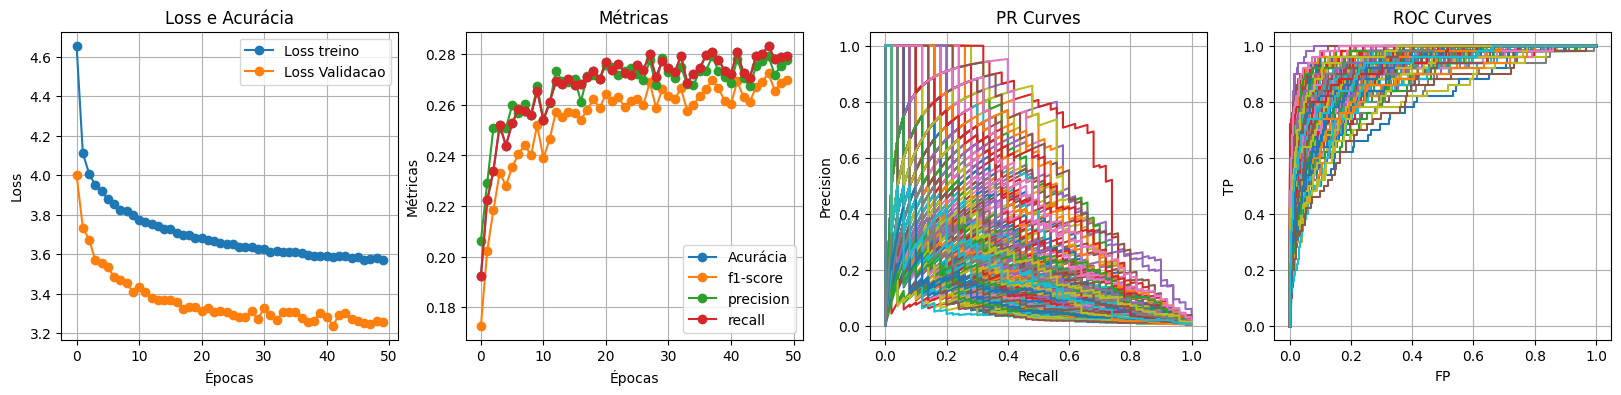

In [ ]:
# TODO
##### Graficos ######
plt.figure(figsize=(20, 4))

#Loss treino x validação
plt.subplot(1, 4, 1)
plt.plot(loss_treino_tiny, 'o-', label=f'Loss treino')
plt.plot(loss_valid_tiny, 'o-', label=f'Loss Validacao')
plt.title("Loss e Acurácia")
plt.ylabel('Loss')
plt.xlabel('Épocas')
plt.legend()
plt.grid()

#Métricas
plt.subplot(1, 4, 2)
plt.plot(acc_final_all_epoca_tiny, 'o-', label=f'Acurácia')
plt.plot(f1_valid_epoca_tiny, 'o-', label=f'f1-score')
plt.plot(precision_valid_epoca_tiny, 'o-', label=f'precision')
plt.plot(recall_valid_epoca_tiny, 'o-', label=f'recall')
plt.title("Métricas")
plt.ylabel('Métricas')
plt.xlabel('Épocas')
plt.legend()
plt.grid()

#Curva PR para todas as classes
plt.subplot(1, 4, 3)
for c in range(len(fpr)):
  plt.plot(r[c], p[c])
plt.title("PR Curves")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()

#Curva ROC para todas as classes
plt.subplot(1, 4, 4)
for c in range(len(fpr)):
  plt.plot(fpr[c], tpr[c])
plt.title("ROC Curves")
plt.xlabel('FP')
plt.ylabel('TP')
plt.grid()

plt.show()

In [ ]:
#Valores de Acurácia
print(f'ultima epoca: {acc_final_all_epoca_tiny[-1]}')
print(f'media: {np.mean(acc_final_all_epoca_tiny)}')

ultima epoca: 0.2793000042438507
media: 0.26768399953842165


In [ ]:
#Valores de f1-score
print(f'ultima epoca: {f1_valid_epoca_tiny[-1]}')
print(f'media: {np.mean(f1_valid_epoca_tiny)}')

ultima epoca: 0.26986292004585266
media: 0.25477358818054197
